# 📘 Text Generation using Vanilla RNN, LSTM, and GRU — Complete Solution

**Problem Statement:** Design and implement a Deep Learning model capable of learning the underlying
structure, grammar, and contextual dependencies of a given text corpus to generate coherent and
meaningful text sequences using:

1. Vanilla RNN
2. LSTM
3. GRU

Then compare training loss, generated text quality, memory handling, and long-term dependency learning.

**Note on dataset:** Instead of downloading an external dataset (which can be slow / network-dependent),
this notebook uses a **direct, in-memory text corpus** defined right in the code. This is the fastest
way to get the pipeline running end-to-end. You can swap in your own paragraph/story later (see the
Student Tasks section) — no download step is required either way.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 📥 Step 1 — Direct In-Memory Text Corpus
No downloads, no external files — the corpus is written directly in code so the notebook runs
immediately on any machine. It's larger than a single-line demo so the models have enough
repeated patterns to actually learn grammar and word order.

In [5]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
artificial intelligence is changing the world rapidly
neural networks learn patterns from large amounts of data
recurrent neural networks process sequences one step at a time
long short term memory networks solve the vanishing gradient problem
gated recurrent units are a simpler alternative to lstm
sequence models are widely used in natural language processing
text generation is a popular application of deep learning
language models predict the probability of the next word
deep learning has revolutionized computer vision and natural language processing
training a neural network requires large amounts of labeled data
the model learns to generate text word by word
lstm networks are effective for long sequences of text
gru networks train faster than lstm networks
recurrent networks struggle with long term dependencies without gates
attention mechanisms further improve sequence modeling performance
"""
print(corpus)
print("Total characters in corpus:", len(corpus))


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
artificial intelligence is changing the world rapidly
neural networks learn patterns from large amounts of data
recurrent neural networks process sequences one step at a time
long short term memory networks solve the vanishing gradient problem
gated recurrent units are a simpler alternative to lstm
sequence models are widely used in natural language processing
text generation is a popular application of deep learning
language models predict the probability of the next word
deep learning has revolutionized computer vision and natural language processing
training a neural network requires large amounts of labeled data
the model learns to generate text word by word
lstm networks are effective for long s

## 🔤 Step 2 — Tokenization & Sequence Creation
We convert the text into integer tokens and build **n-gram style sequences** so the model learns
to predict the next word given the previous words in a line.

In [6]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.strip().split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding="pre")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Number of training sequences:", len(input_sequences))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Max sequence length:", max_len)

Vocabulary size: 96
Number of training sequences: 153
X shape: (153, 9)
y shape: (153,)
Max sequence length: 10


## 🏗️ Step 3 — Reusable Model Builder
A single helper function builds the same architecture (Embedding → recurrent layer → Dense/softmax)
for RNN, LSTM, or GRU, so the three models are directly comparable — the only thing that changes
is the recurrent layer type.

In [7]:
def build_model(rnn_type="SimpleRNN", units=64, embedding_dim=32):
    layer_map = {
        "SimpleRNN": SimpleRNN,
        "LSTM": LSTM,
        "GRU": GRU,
    }
    RecurrentLayer = layer_map[rnn_type]

    model = Sequential([
        Embedding(total_words, embedding_dim, input_length=max_len - 1),
        RecurrentLayer(units),
        Dense(total_words, activation="softmax"),
    ])

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"],
    )
    return model

## 🧠 Step 4 — Train Vanilla RNN
The baseline model. It struggles with long-term dependencies because of the vanishing gradient
problem — earlier words in a sequence have less influence on later predictions.

In [8]:
rnn_model = build_model("SimpleRNN")
rnn_model.summary()

rnn_history = rnn_model.fit(X, y, epochs=150, verbose=0)
print("Vanilla RNN training completed. Final loss:", rnn_history.history["loss"][-1])

/Users/ankitkumar/.pyenv/versions/3.11.8/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Vanilla RNN training completed. Final loss: 0.17746815085411072


## 🔒 Step 5 — Train LSTM
LSTM uses **input, forget, and output gates** to preserve long-term memory and mitigate the
vanishing gradient problem.

In [9]:
lstm_model = build_model("LSTM")
lstm_model.summary()

lstm_history = lstm_model.fit(X, y, epochs=150, verbose=0)
print("LSTM training completed. Final loss:", lstm_history.history["loss"][-1])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

LSTM training completed. Final loss: 0.7000446319580078


## ⚡ Step 6 — Train GRU
GRU uses **reset and update gates** — fewer parameters than LSTM, often trains faster, and gives
similar quality results on smaller datasets.

In [10]:
gru_model = build_model("GRU")
gru_model.summary()

gru_history = gru_model.fit(X, y, epochs=150, verbose=0)
print("GRU training completed. Final loss:", gru_history.history["loss"][-1])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

GRU training completed. Final loss: 0.175988107919693


## 📉 Step 7 — Compare Training Loss & Accuracy

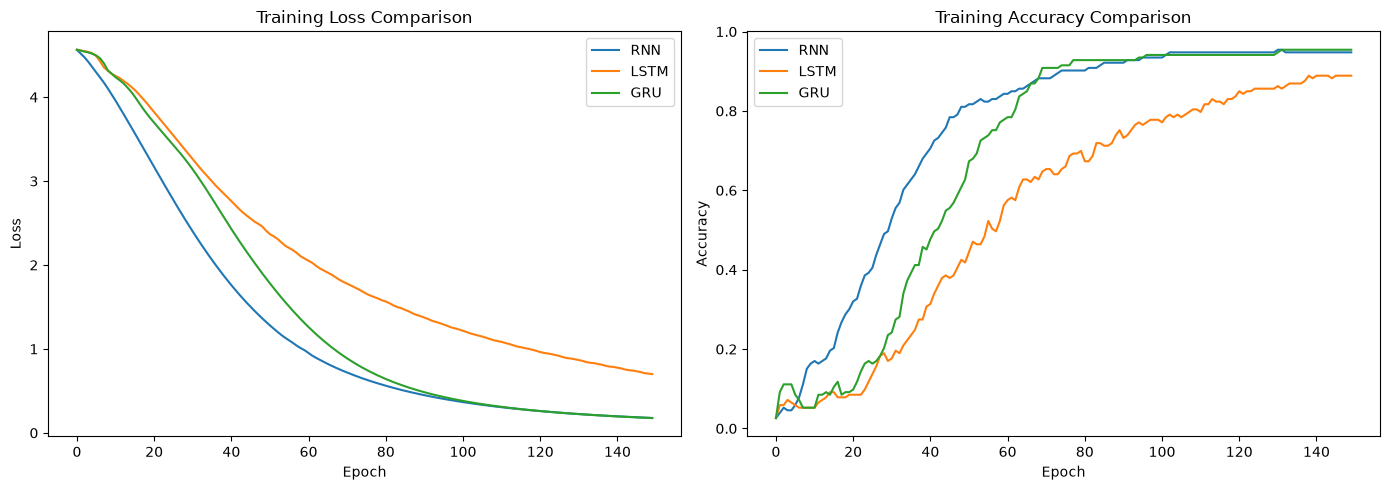

Model     Final Loss     Final Accuracy 
RNN       0.1775         0.9477         
LSTM      0.7000         0.8889         
GRU       0.1760         0.9542         


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_history.history["loss"], label="RNN")
axes[0].plot(lstm_history.history["loss"], label="LSTM")
axes[0].plot(gru_history.history["loss"], label="GRU")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss Comparison")
axes[0].legend()

axes[1].plot(rnn_history.history["accuracy"], label="RNN")
axes[1].plot(lstm_history.history["accuracy"], label="LSTM")
axes[1].plot(gru_history.history["accuracy"], label="GRU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{'Model':<10}{'Final Loss':<15}{'Final Accuracy':<15}")
print(f"{'RNN':<10}{rnn_history.history['loss'][-1]:<15.4f}{rnn_history.history['accuracy'][-1]:<15.4f}")
print(f"{'LSTM':<10}{lstm_history.history['loss'][-1]:<15.4f}{lstm_history.history['accuracy'][-1]:<15.4f}")
print(f"{'GRU':<10}{gru_history.history['loss'][-1]:<15.4f}{gru_history.history['accuracy'][-1]:<15.4f}")

## ✍️ Step 8 — Text Generation Function
Given a seed phrase, the model repeatedly predicts the next word and appends it to the sequence.

In [ ]:
def generate_text(model, seed_text, next_words=8, temperature=1.0):
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding="pre")

        preds = model.predict(token_list, verbose=0)[0]

        preds = np.asarray(preds).astype("float64")
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        predicted_index = np.random.choice(len(preds), p=preds)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        if output_word == "":
            break
        result += " " + output_word
    return result

## 🧪 Step 9 — Generate Text Samples

In [13]:
seed = "deep learning"

print("RNN :", generate_text(rnn_model, seed, next_words=8, temperature=0.7))
print("LSTM:", generate_text(lstm_model, seed, next_words=8, temperature=0.7))
print("GRU :", generate_text(gru_model, seed, next_words=8, temperature=0.7))

print()
seed2 = "neural networks"
print("RNN :", generate_text(rnn_model, seed2, next_words=8, temperature=0.7))
print("LSTM:", generate_text(lstm_model, seed2, next_words=8, temperature=0.7))
print("GRU :", generate_text(gru_model, seed2, next_words=8, temperature=0.7))

RNN : deep learning is changing computer vision and natural language processing
LSTM: deep learning models can generate meaningful sentences natural word gru
GRU : deep learning is transforming artificial intelligence is changing the world

RNN : neural networks learn patterns from large amounts of data of
LSTM: neural networks networks process used step at language processing time
GRU : neural networks are effective for long sequences of text time
